## Inputs Iniciais

### Imports

In [104]:
# imports
import os
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import itertools


## Definição de funções e classes

Inicialmente isto estaria em scripts separados, mas de cada vez que é feita uma alteração, é necessário reiniciar o kernell do notebook, o que dificulta o trabalho pelo tempo perdido em re-runs.

Por esse motivo todas as definições passaram para dentro do notebook.

### market.py

In [ ]:
def get_stock_data(companies):
    """
    Reads CSV files for each company, extracts the 'Date' and 'Close' columns, and merges them into a single DataFrame.
    The resulting DataFrame has 'Date' as the index and each company's closing price as a column. 
    Finally, it drops the 'Date' column and returns the values as a NumPy array.

    Parameters:
    companies (list of str): List of company ticker symbols corresponding to the CSV files

    Returns:
    np.ndarray: A 2D array where each column corresponds to a company's closing prices and each row corresponds to a date.
    """
    output = pd.DataFrame(columns=['Date'])          # Initialize an empty DataFrame with 'Date' column
    is_first = True                                  # Flag to handle the first company separately for merging
    for company in companies:                        # Loop through each company ticker symbol
        df = pd.read_csv(f'data/{company}.csv')      # Read the CSV file for the current company
        df = df[['Date','Close']]                    # Keep only the 'Date' and 'Close' columns
        df = df.rename(columns = {'Close': company}) # Rename the 'Close' column to the company ticker symbol for clarity
        if is_first:                                 # For the first company, we can directly use its DataFrame as the output
            output = df.copy()                       # Copy the first company's DataFrame to the output
            is_first = False                         # Set the flag to False after processing the first company
        else:
            output = output.merge(df, on='Date')     # Merge the current company's DataFrame with the output DataFrame on the 'Date' column
    output = output.drop(columns = ['Date'])         # Drop the 'Date' column as it's no longer needed after merging
    return output.values                             # Return the values of the DataFrame as a NumPy array

# yfinance output format has changed over time (often MultiIndex columns).
# This helper extracts the "Close" price robustly across formats.
def extract_close(download_df: pd.DataFrame) -> pd.DataFrame:
    if isinstance(download_df.columns, pd.MultiIndex):
        # Common formats:
        # 1) columns = (Price, Ticker)   e.g., ("Close", "AAPL")
        # 2) columns = (Ticker, Price)   e.g., ("AAPL", "Close")
        lvl0 = set(map(str, download_df.columns.get_level_values(0)))
        lvl1 = set(map(str, download_df.columns.get_level_values(1)))
        if "Close" in lvl0:
            close_df = download_df["Close"]
        elif "Close" in lvl1:
            close_df = download_df.xs("Close", level=1, axis=1)
        else:
            raise ValueError("Couldn't find 'Close' in downloaded columns. Inspect download_df.columns.")
    else:
        # Single ticker case or older formats
        if "Close" in download_df.columns:
            close_df = download_df[["Close"]].copy()
        else:
            raise ValueError("Couldn't find 'Close' in downloaded columns. Inspect download_df.columns.")
    return close_df

class market:   
    """
    Simulates a stock trading environment for reinforcement learning.
    Manages portfolio state, executes trades, computes rewards, and provides
    discretized state representations based on volatility and momentum signals.
    """                                          
    def __init__(self, companies, budget=1e4, volatility_window=20):
        """
        Initializes the market environment with historical stock data.

        Parameters:
            companies (list of str): Ticker symbols to trade (e.g. ['AAPL', 'MSFT']).
            budget (float): Starting cash budget. Default is 10,000.
            volatility_window (int): Lookback window in days for volatility and momentum calculations. Default is 20.
        """
        self.data = get_stock_data(companies)
        self.budget = budget
        self.total_days = self.data.shape[0]
        self.total_companies = self.data.shape[1]
        self.index_actions = np.arange(3**self.total_companies)
        self.action_list = list(map(list,itertools.product([0,1,2],repeat=self.total_companies)))
        self.state_size = self.total_companies * 2 + 1
        # precompute volatility once: rolling std of daily returns, discretized into 0=low, 1=medium, 2=high
        self.volatility = self._compute_volatility(volatility_window)
        self.momentum = self._compute_momentum(volatility_window)
        self.start()

    def get_discretized_state(self):
        """
        Returns a compact discrete state combining volatility and holdings.
        Used as the Q-table key for the discretized Q-learning agent.

        Returns:
            tuple: Integer tuple of length (total_companies * 2) containing
                volatility levels (0=low, 1=medium, 2=high) followed by
                holdings flags (0=not holding, 1=holding) per company.
                e.g. (0, 1) for 1 company: low volatility, holding.
        """
        # combines volatility signal with holdings info into a compact discrete state
        # volatility: 0=low, 1=medium, 2=high — one value per company
        vol = self.volatility[self.today]
        # holdings: 0=not holding, 1=holding — one value per company
        holdings = (self.stocks > 0).astype(int)
        # concatenate into a single tuple: (vol_company1, ..., holding_company1, ...)
        return tuple(np.concatenate([vol, holdings]))
    
    def get_discretized_state_v2(self):
        """
        Returns a compact discrete state combining volatility, momentum and holdings.
        Extended version of get_discretized_state with momentum as an additional feature.

        Returns:
            tuple: Integer tuple of length (total_companies * 3) containing
                volatility levels (0=low, 1=medium, 2=high), momentum levels
                (0=falling, 1=flat, 2=rising), and holdings flags (0=not holding,
                1=holding) per company.
                e.g. (0, 2, 1) for 1 company: low volatility, rising, holding.
        """
        vol      = self.volatility[self.today]
        mom      = self.momentum[self.today]
        holdings = (self.stocks > 0).astype(int)
        return tuple(np.concatenate([vol, mom, holdings]))

    def get_episode_value(self):
        """
        Returns the current total portfolio value (cash + stock holdings).

        Returns:
            float: Total portfolio value in USD.
        """
        return self._get_eval()

    def start(self):
        """
        Resets the environment to the beginning of the dataset.
        Call this at the start of each episode.

        Returns:
            np.ndarray: Initial state vector of shape (state_size,) containing
                        stock holdings, current prices, and available cash.
        """
        self.today = 0
        self.stocks = np.zeros(self.total_companies)
        self.stock_price = self.data[self.today]
        self.money_available = self.budget
        return self._get_state()

    def new_day(self, action):
        """
        Advances the environment by one trading day and executes the given action.

        Parameters:
            action (int): Index into action_list representing the trade decision
                        for each company (0=sell, 1=hold, 2=buy).

        Returns:
            tuple:
                np.ndarray: Next state vector of shape (state_size,).
                float: Reward as absolute change in portfolio value (USD).
                bool: True if the episode is finished (last trading day).
        """
        previous_val = self._get_eval()
        self.today += 1
        self.stock_price = self.data[self.today]
        self._exchange(action)
        current_val = self._get_eval()
        reward = current_val - previous_val
        done = self.today == (self.total_days - 1)
        return self._get_state(), reward, done

    def new_day_normalized(self, action):
        """
        Advances the environment by one trading day and executes the given action.
        Same as new_day but returns a normalised reward as percentage return,
        which reduces scale sensitivity in Q-value updates.

        Parameters:
            action (int): Index into action_list representing the trade decision
                        for each company (0=sell, 1=hold, 2=buy).

        Returns:
            tuple:
                np.ndarray: Next state vector of shape (state_size,).
                float: Reward as percentage change in portfolio value (e.g. 0.02 = +2%).
                bool: True if the episode is finished (last trading day).
        """
        previous_val = self._get_eval()
        self.today += 1
        self.stock_price = self.data[self.today]
        self._exchange(action)
        current_val = self._get_eval()
        reward_normalized = (current_val - previous_val) / previous_val
        done = self.today == (self.total_days - 1)
        return self._get_state(), reward_normalized, done

    def _exchange(self, action): # _ before method name indicates it's intended to be internal/private
        """
        Executes buy and sell orders for the given action.
        Sells all shares of companies in the sell list, then buys as many
        shares as possible (one at a time, round-robin) for companies in
        the buy list until the budget is exhausted.

        Parameters:
            action (int): Index into action_list representing the trade decision
                        for each company (0=sell, 1=hold, 2=buy).
        """
        actions = self.action_list[action] # [0,1,0]

        sell_list = []
        buy_list = []

        for i, action in enumerate(actions):
            if action == 0:
                sell_list.append(i)
            elif action ==2:
                buy_list.append(i)

        if sell_list:
            for i in sell_list:
                self.money_available += self.stock_price[i] * self.stocks[i]
                self.stocks[i] = 0

        if buy_list:
            broke = False
            cur_stock_prices = [self.stock_price[i] for i in buy_list]
            while not broke:
                for i in buy_list:
                    if self.money_available > self.stock_price[i]:
                        self.money_available -= self.stock_price[i]
                        self.stocks[i] += 1
                    else: # all(self.money_available < cur_stock_prices):
                        broke = True


    def _get_eval(self): # _ before method name indicates it's intended to be internal/private
        """
        Computes the current total portfolio value.

        Returns:
            float: Sum of stock holdings market value and available cash (USD).
        """
        return self.stocks.dot(self.stock_price) + self.money_available

    def _get_state(self): # _ before method name indicates it's intended to be internal/private
        """
        Builds the raw state vector for the current day.
        Used by new_day and start — not used by the discretized Q-learning agent.

        Returns:
            np.ndarray: State vector of shape (state_size,) containing
                        [stocks_held x N, current_prices x N, money_available]
                        where N is total_companies.
        """
        state = np.zeros(self.state_size) #[0,0,0,0,0,0,0]
        state[:self.total_companies] = self.stocks
        state[self.total_companies:self.total_companies*2] = self.stock_price
        state[-1] = self.money_available
        return state
    
    def _compute_volatility(self, window): # _ before method name indicates it's intended to be internal/private
        """
        Precomputes a discretized volatility signal for all days and companies.
        Uses rolling standard deviation of daily returns, split into terciles.

        Parameters:
            window (int): Lookback window in days for the rolling std calculation.

        Returns:
            np.ndarray: 2D integer array of shape (total_days, total_companies)
                        where values are 0=low, 1=medium, 2=high volatility.
        """
        # compute daily returns: (price_today - price_yesterday) / price_yesterday
        prices = pd.DataFrame(self.data)
        daily_returns = prices.pct_change()

        # rolling std of returns over 'window' days — higher = more volatile
        rolling_vol = daily_returns.rolling(window=window).std()

        # discretize into 3 bins per company: 0=low, 1=medium, 2=high
        # using percentile-based cuts so bins are balanced across the data
        discretized = np.zeros_like(self.data, dtype=int)
        for company in range(self.total_companies):
            col = rolling_vol.iloc[:, company].fillna(0).values
            low_threshold = np.percentile(col, 33)
            high_threshold = np.percentile(col, 66)
            for day in range(self.total_days):
                if col[day] <= low_threshold:
                    discretized[day, company] = 0  # low volatility
                elif col[day] <= high_threshold:
                    discretized[day, company] = 1  # medium volatility
                else:
                    discretized[day, company] = 2  # high volatility
        return discretized
    
    def _compute_momentum(self, window): # _ before method name indicates it's intended to be internal/private
        """
        Precomputes a discretized momentum signal for all days and companies.
        Uses N-day return to classify price trend direction.

        Parameters:
            window (int): Lookback window in days for the return calculation.

        Returns:
            np.ndarray: 2D integer array of shape (total_days, total_companies)
                        where values are 0=falling (<-1%), 1=flat (-1% to +1%),
                        2=rising (>+1%).
        """
        prices = pd.DataFrame(self.data)
        # N-day return: (price_today - price_N_days_ago) / price_N_days_ago
        momentum = prices.pct_change(periods=window).fillna(0).values

        discretized = np.zeros_like(self.data, dtype=int)
        for company in range(self.total_companies):
            col = momentum[:, company]
            for day in range(self.total_days):
                if col[day] < -0.01:
                    discretized[day, company] = 0  # falling
                elif col[day] <= 0.01:
                    discretized[day, company] = 1  # flat
                else:
                    discretized[day, company] = 2  # rising
        return discretized

### qlearning_agent.py

In [ ]:
class qlearning_agent:
    """
    Tabular Q-Learning agent for stock trading.
    Learns a Q-table mapping (state, action) pairs to expected future rewards
    using the Q-learning update rule with epsilon-greedy exploration.
    """
    def __init__(self, 
                num_actions, 
                num_companies, 
                alpha=0.1, 
                gamma=0.95, 
                epsilon=1.0, 
                epsilon_decay=0.995, 
                epsilon_min=0.01
                ):
        """
        Initializes the Q-learning agent.

        Parameters:
            num_actions (int): Total number of possible actions (3^num_companies).
            num_companies (int): Number of companies being traded.
            alpha (float): Learning rate. Controls how much Q-values are updated
                           on each step. Default is 0.1.
            gamma (float): Discount factor. Controls how much future rewards are
                           valued vs immediate rewards. Default is 0.95.
            epsilon (float): Initial exploration rate. Default is 1.0 (fully random).
            epsilon_decay (float): Multiplicative decay applied to epsilon after
                                   each episode. Default is 0.995.
            epsilon_min (float): Minimum exploration rate epsilon can decay to.
                                 Default is 0.01.
        """
    
        # ===== General RL agent attributes =====

        # save number of actions for later use
        self.num_actions = num_actions

        # save number of companies for later use
        self.num_companies = num_companies

        # learning rate: how much we update Q values on each step
        self.alpha = alpha

        # discount factor: how much we value future rewards vs immediate rewards
        self.gamma = gamma

        # exploration rate: probability of choosing a random action
        self.epsilon = epsilon

        # decay rate for epsilon: how quickly epsilon decreases towards epsilon_min
        self.epsilon_decay = epsilon_decay

        # minimum exploration rate: lowest value epsilon can decay to
        self.epsilon_min = epsilon_min

        # ===== Q-learning specific attributes =====

        # Q-table: dictionary mapping state -> array of Q values, one per action
        # equivalent to Q[s][a] in the teacher's code
        # we use a dict because the state space is too large to pre-build (unlike grid world)
        self.Q = {}

        self.state_visits = {}

        self.state_action_visits = {}

    # ===== Internal helper methods =====

    def _state_key(self, state): # _ before method name indicates it's intended to be internal/private
        """
        Converts a state array to a hashable tuple for use as a Q-table key.

        Parameters:
            state: State representation (numpy array or tuple).

        Returns:
            tuple: Hashable version of the state.
        """
        # states are numpy arrays, which can't be dict keys, so we convert them to tuples
        return tuple(state)

    def _get_q_values(self, state_key): # _ before method name indicates it's intended to be internal/private
        """
        Returns Q-values for a given state, initializing to zeros if unseen.

        Parameters:
            state_key (tuple): Hashable state key.

        Returns:
            np.ndarray: Q-values of shape (num_actions,).
        """
        # if we've never seen this state before, initialize Q values to zero for all actions
        # equivalent to Q[s] = np.zeros(num_actions) for Grid World problem
        if state_key not in self.Q:
            self.Q[state_key] = np.zeros(self.num_actions)
        return self.Q[state_key]
    
    # ===== Main agent methods =====
    
    def act(self, state):
        """
        Selects an action using epsilon-greedy policy.

        Parameters:
            state: Current state (numpy array or tuple).

        Returns:
            int: Selected action index.
        """
        # epsilon-greedy: explore with probability epsilon, otherwise exploit (choose action with highest Q value)
        # equivalent to epsilon_greedy(s, eps) in Grid World problem
        state_key = self._state_key(state)
        self._get_q_values(state_key) # initialize Q values if state is new

        if np.random.random() < self.epsilon:
            return np.random.choice(self.num_actions) # explore: choose a random action
        else:
            return np.argmax(self.Q[state_key]) # exploit: choose action with highest Q value
        
    def learn(self, state, action, reward, next_state, done):
        """
        Updates the Q-table using the Q-learning update rule.
        Decays epsilon at the end of each episode.

        Parameters:
            state: Current state.
            action (int): Action taken.
            reward (float): Reward received.
            next_state: Next state after action.
            done (bool): True if the episode has ended.
        """
        # q-learning update rule:
        state_key = self._state_key(state)
        next_state_key = self._state_key(next_state)

        current_q = self._get_q_values(state_key)[action]
        next_q_values = self._get_q_values(next_state_key)

        if done:
            # if episode is done, there's no future reward to consider
            target = reward
        else:
            # bootstrapping: estimate future value using next best action
            target = reward + self.gamma * np.max(next_q_values)

        # update q value for this (state, action) pair
        self.Q[state_key][action] += self.alpha * (target - current_q)

        # decay epsilon after each learning step
        if done:
            self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

        if state_key not in self.state_visits:
            self.state_visits[state_key] = 0
        self.state_visits[state_key] += 1

        pair = (state_key, action)
        if pair not in self.state_action_visits:
            self.state_action_visits[pair] = 0
        self.state_action_visits[pair] += 1

    def q_table_stats(self, run=None):
        """
        Prints a summary of Q-table coverage and exploration state.

        Parameters:
            run (int, optional): Run number to display in the header label.
        """
        total_states = len(self.Q)
        visited_more_than_once = sum(1 for v in self.state_visits.values() if v > 1)
        label = f"Run {run}" if run is not None else "Agent"

        print(f"--- {label} ---")
        print(f"Unique states visited:          {total_states}")
        print(f"States visited more than once:  {visited_more_than_once} / {total_states} ({100 * visited_more_than_once / total_states:.1f}%)")
        print(f"Total Q-table entries:          {total_states * self.num_actions}")
        print(f"Actions per state:              {self.num_actions}")
        print(f"Current epsilon:                {self.epsilon:.4f}")

### buy_hold_agent.py

In [ ]:
class buy_hold_agent:
    """
    Deterministic buy and hold baseline agent.
    Buys all available stocks on the first day and holds until the end.
    Since it is fully deterministic, running multiple episodes produces
    identical results — use as a single-episode baseline reference.
    """
    def __init__(self, num_companies):
        """
        Initializes the buy and hold agent.

        Parameters:
            num_companies (int): Number of companies being traded.
        """
        # store how many companies exist in the market
        self.num_companies = num_companies
        # flag to track if this is the first step of the episode
        self.first_step = True

    def act(self, state):
        """
        Returns the buy-all action on the first step, hold-all on all subsequent steps.
        Actions are encoded in base 3 (0=sell, 1=hold, 2=buy) per company.

        Parameters:
            state: Current state (not used — agent is stateless except for first_step).

        Returns:
            int: Action index into market.action_list.
        """
        # on the first step, buy everything
        if self.first_step:
            # mark that we have already taken the first step
            self.first_step = False
            # build the "buy all" action index
            # actions are encoded in base 3: 0=sell, 1=hold, 2=buy
            # for each company i, add 2 * 3^i to get the index for "buy all"
            action = 0
            for i in range(self.num_companies):
                action += 2 * (3 ** i)
            return action

        # on all subsequent steps, hold everything
        # for each company i, add 1 * 3^i to get the index for "hold all"
        action = 0
        for i in range(self.num_companies):
            action += 1 * (3 ** i)
        return action

    def reset(self):
        """
        Resets the agent so it buys again at the start of a new episode.
        Called automatically by play_episode if the agent has a reset method.
        """
        # reset the flag so the agent buys again at the start of a new episode
        self.first_step = True

### momentum_agent.py

In [ ]:
class momentum_agent:
    """
    Deterministic momentum-based trading agent.
    Buys when price is trending up, sells when trending down, holds when flat,
    based on the price difference over a lookback window.
    Since it is fully deterministic given the same market data, running multiple
    episodes produces identical results.
    """
    def __init__(self, num_actions, num_companies, window=3):
        """
        Initializes the momentum agent.

        Parameters:
            num_actions (int): Total number of possible actions (3^num_companies).
            num_companies (int): Number of companies being traded.
            window (int): Lookback window in days for momentum calculation.
                          Default is 3.
        """
        self.num_actions = num_actions
        self.num_companies = num_companies
        self.window = window
        self.history = []

    def act(self, state):
        """
        Selects an action based on price momentum over the lookback window.
        Returns a random action for the first 'window' steps while building history.

        Parameters:
            state (np.ndarray): Current state vector structured as
                                [holdings x N, prices x N, cash].

        Returns:
            int: Action index into market.action_list.
        """
        prices = state[self.num_companies:2*self.num_companies] # slicer para obter apenas os preços. Vai desde o numero de empresas até o dobro do número de empresas, assumindo que o estado é estruturado como [holdings, prices]
        self.history.append(prices.copy()) # adiciona os preços atuais ao histórico. Usa copy para evitar que futuras modificações em prices afetem o histórico

        if len(self.history) < self.window + 1: # se ainda não houver histórico suficiente para calcular o momentum, escolhe uma ação aleatória
            return np.random.choice(self.num_actions)

        # Calculate momentum
        momentum = self.history[-1] - self.history[-self.window-1] # calcula o momentum como a diferença entre o preço atual e o preço de n passos atrás (definido pela janela)
        actions = []

        for m in momentum:
            if m > 0:
                actions.append(2)  # Buy
            elif m < 0:
                actions.append(0)  # Sell
            else:
                actions.append(1)  # Hold

        # Convert to index
        action_index = 0
        for i, a in enumerate(actions):
            action_index += a * (3 ** (self.num_companies - i - 1))

        return action_index

    def reset(self):
        """
        Clears the price history so the agent starts fresh for a new episode.
        """
        self.history = []

### random_agent.py

In [ ]:
class random_agent:
    """
    Random baseline agent.
    Selects a uniformly random action at every step, regardless of state.
    Used as a lower-bound baseline to verify that learning agents do better
    than pure chance.
    """
    def __init__(self, num_actions):
        """
        Initializes the random agent.

        Parameters:
            num_actions (int): Total number of possible actions (3^num_companies).
        """
        self.num_actions = num_actions
        
    def act(self, state):
        """
        Returns a uniformly random action.

        Parameters:
            state: Current state (not used).

        Returns:
            int: Random action index.
        """
        return np.random.choice(self.num_actions)

### training_functions.py

In [ ]:
def play_episode(agent, market):
    """
    Runs a single episode from start to finish without learning.
    Used for deterministic agents (random, momentum, buy & hold)
    that do not call agent.learn().

    Parameters:
        agent: Any agent with an act(state) method.
        market: market environment instance.

    Returns:
        float: Final portfolio value at the end of the episode.
    """
    state = market.start()
    done = False

    while not done:
        action = agent.act(state)
        next_state, reward, done = market.new_day(action)
        state = next_state

    return market.get_episode_value()


def play_episode_sequence(agent, market, n_episodes):
    """
    Runs multiple episodes in sequence and records the final portfolio value
    of each. Resets the market at the start of each episode via play_episode.
    Note: does not reset the agent between episodes.

    Parameters:
        agent: Any agent with an act(state) method.
        market: market environment instance.
        n_episodes (int): Number of episodes to run.

    Returns:
        list of float: Final portfolio value for each episode.
    """
    values_list = []
    for episode in range(n_episodes):
        value = play_episode(agent, market)
        values_list.append(value)
    return values_list

### plotting_functions.py

In [111]:
def plot_value_evolution(compilation_runs, label, ax, window=20, color='blue'):
    """
    Plots the evolution of portfolio values across episodes for multiple runs.
    
    Parameters:
    - compilation_runs: List of lists, where each inner list contains the final portfolio values for each episode in a run.
    - label: Label for the plot legend.
    - ax: Matplotlib axis to plot on.
    - window: Window size for moving average smoothing.
    - color: Color for the plot.
    """
    # shape of compilation_runs is (n_runs, n_episodes)
    compilation_runs_array = np.array(compilation_runs)  # Convert to numpy array for easier calculations

    # moving average per run, then average across runs
    mov_avg = np.array([np.convolve(run, np.ones(window)/window, mode='valid') for run in compilation_runs_array])
    mean_mov_avg = mov_avg.mean(axis=0)
    std_mov_avg = mov_avg.std(axis=0)
    x = range(window - 1, window - 1 + len(mean_mov_avg))  # Adjust x-axis for smoothing

    ax.plot(x, mean_mov_avg, label=label, color=color)
    ax.fill_between(x, mean_mov_avg - std_mov_avg, mean_mov_avg + std_mov_avg, alpha=0.2, color=color)


## Inicialização do ambiente

### Download inicial dos dados dos tickers em .csv

In [112]:
# --- Download & save data in the same format expected by market.py (Date + Close) ---
tickers = ["NOK", "AAPL"]#, "MSFT", "GOOGL", "AMZN"]

data = yf.download(tickers, start="2010-01-01", auto_adjust=False, group_by="column", progress=False)

close = extract_close(data)

os.makedirs("data", exist_ok=True)

for ticker in tickers:
    if ticker not in close.columns:
        # In some edge cases yfinance may return a different naming, so we fail loudly.
        raise KeyError(f"Ticker '{ticker}' not found in Close data columns: {list(close.columns)}")
    single = close[[ticker]].reset_index()
    single.columns = ["Date", "Close"]

    # Match the legacy CSV date format found in the repository: dd-mm-YYYY
    single["Date"] = pd.to_datetime(single["Date"]).dt.strftime("%d-%m-%Y")

    single.to_csv(f"data/{ticker}.csv", index=False)

### Definição inicial da variável env. O ambiente é inicializado todas as vezes que se chama a função play_episode.

In [113]:
env = market(tickers, budget=1e4)

## Desafio (Trabalho Final) — *Market RL Agent*

O objetivo é criares um **agente** capaz de interagir com o ambiente `market` (definido em `market.py`), tomando decisões de ação ao longo do tempo com base no estado observado.

> **Importante:** não se foquem demasiado em “ganhar” ao `RandomAgent`. O foco é **aprofundar um conceito da aula**, justificar decisões e mostrar pensamento crítico.  
> **Serás avaliado mais pela interpretação do que pelo melhor resultado.**

---

### Tarefa Principal

Escolhe **apenas UMA** das abordagens abaixo e resolve o problema.

#### Opção A — Monte Carlo (MC)
- Define claramente o que é um **episódio** no ambiente `market`.
- Escolhe MC **First-Visit** ou **Every-Visit**.
- Implementa:
  - política
  - avaliação/controlo (estimativa de \(V(s)\) ou \(Q(s,a)\))
  - mecanismo de exploração
- Discute: **variança**, necessidade de múltiplas amostras, impacto do tempo e escolha das recompensas.

#### Opção B — Temporal Difference (TD) ✅
- Escolhe TD(0) / SARSA / **Q-Learning** ✅.
- Implementa:
  - tabela de \(Q(s,a)\) (ou uma aproximação simples, se justificares) ✅
  - exploração (ε-greedy) ✅
  - learning rate (α) e discount (γ) ✅
- Discute: **bootstrapping**, estabilidade, exploração vs exploração, convergência.

---

### Criatividade (Obrigatório)
Experimenta **pelo menos 2** escolhas “criativas”, por exemplo:
- **state abstraction** (ex.: discretização de retornos, bins, features simples) ✅
- **reward shaping** (e justificar impactos)
- **multi-start** (várias corridas e comparar) ✅
- **ε schedule** (fixo vs decaimento) ✅
- **γ/α schedules** (constante vs adaptativo)
- mistura de métodos (ex.: MC para inicializar, TD para refinar)
- diferentes representações para o estado (mais/menos informação)

---

### Experiências Obrigatórias (para qualquer opção)
1. Corre o teu agente **várias vezes** (pelo menos **5** runs), com **seeds diferentes**. ✅
2. Varia parâmetros relevantes (pelo menos **2 configurações** por agente). ✅
3. Guarda e mostra o **histórico do valor/custo** ao longo do treino (learning curve). ✅
4. Faz pelo menos uma comparação com um baseline simples (ex.: `RandomAgent` e/ou `MomentumAgent`). ✅

**Gráficos obrigatórios:**
- Evolução do **retorno/valor do episódio** ao longo do treino (por episódio ou por iterações). ✅
- Idealmente: inclui média móvel (ex.: janela 20) + dispersão (min/max ou std) entre runs. ✅

**Outputs recomendados:**
- Gráficos: retorno por episódio (com várias seeds) ✅
- Uma tabela pequena: configuração → melhor retorno → média/variância ✅
- Comentário crítico: “o que funcionou / o que não funcionou / porquê” ✅

---

### O que entregar

Um **Jupyter Notebook** contendo:
- Código (bem organizado e comentado)
- Experiências (várias runs, vários parâmetros)
- Interpretação crítica (texto)

Um **video** com uma breve apresentação do trabalho (~5 minutos) em que correm o trabalho e comentam as escolhas feitas  
(sugestão: OBS Studio para gravação do ecrã).

**Enviar o notebook e video da apresentação para (ivoacnogueira@gmail.com ou ivo.nogueira@isag.pt) até dia 15 de Março de 2026**.

---

### Regras

- Trabalho individual
- Código original
- Permitido: `numpy`, `pandas`, `matplotlib` (e bibliotecas standard do Python)
- Não usar bibliotecas RL/otimização prontas (ex.: `stable-baselines`, `gymnasium` trainers, `scipy.optimize`, etc.)
- Se usares uma aproximação de função (ex.: regressão simples), justifica claramente e mantém a implementação “manual” e pedagógica.

# Resolução - Opção B - Temporal Difference (Q-Learning)

## Visualizar evolução do preço para contexto

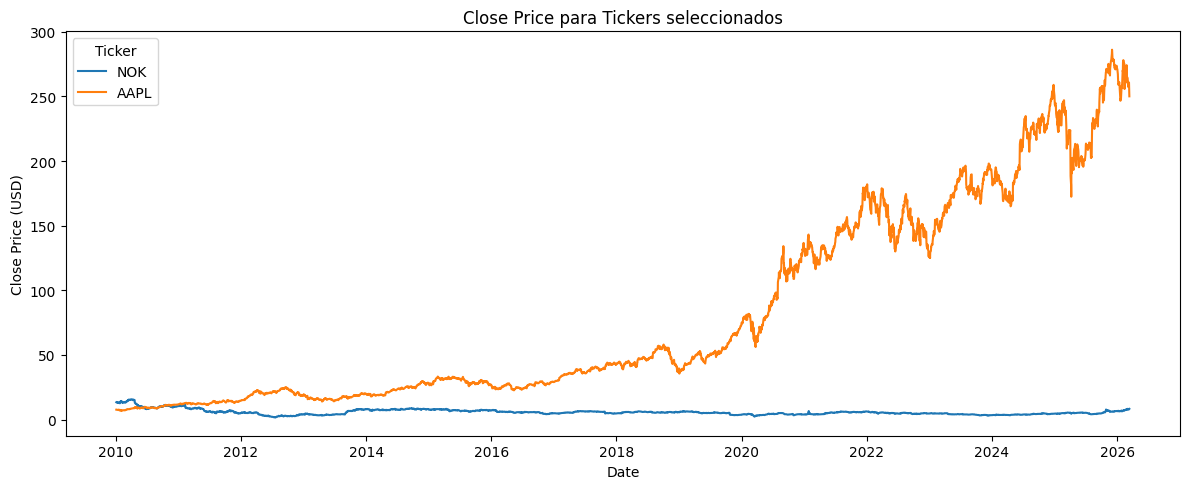

In [114]:
type(close)
close.head()
close[tickers].plot(
    figsize=(12, 5), 
    title="Close Price para Tickers seleccionados")
plt.xlabel('Date')
plt.xticks(rotation=0, ha='center')
plt.ylabel('Close Price (USD)')
plt.tight_layout()
plt.show()


## Baseline - Random Agent 5 x 50 episódios

In [115]:
n_runs = 2
n_episodes_per_run = 50 

compilation_random_agent = []

for seed in range(n_runs):
    np.random.seed(seed)
    agent = random_agent(num_actions=len(env.index_actions))
    run_values = play_episode_sequence(agent, env, n_episodes_per_run)
    compilation_random_agent.append(run_values)


## Baseline - Momentum Agent 5 x 50 episódios

Window = 3

In [116]:
n_runs = 1
n_episodes_per_run = 50 

compilation_momentum_agent_w3 = []

for seed in range(n_runs):
    np.random.seed(seed)
    agent = momentum_agent(num_actions = len(env.index_actions), num_companies = env.total_companies)
    run_values = play_episode_sequence(agent, env, n_episodes_per_run)
    compilation_momentum_agent_w3.append(run_values)

Window = 20

In [117]:
n_runs = 1
n_episodes_per_run = 50 

compilation_momentum_agent_w20 = []

for seed in range(n_runs):
    np.random.seed(seed)
    agent = momentum_agent(num_actions = len(env.index_actions), num_companies = env.total_companies, window=20)
    run_values = play_episode_sequence(agent, env, n_episodes_per_run)
    compilation_momentum_agent_w20.append(run_values)

Window = 50

In [118]:
n_runs = 1
n_episodes_per_run = 50 

compilation_momentum_agent_w50 = []

for seed in range(n_runs):
    np.random.seed(seed)
    agent = momentum_agent(num_actions = len(env.index_actions), num_companies = env.total_companies, window=50)
    run_values = play_episode_sequence(agent, env, n_episodes_per_run)
    compilation_momentum_agent_w50.append(run_values)

## Baseline - Buy and Hold Agent

In [119]:
agent = buy_hold_agent(num_companies = env.total_companies)
buy_hold_value = play_episode(agent, env)

## Q-learning agent (Primeiro Teste)

In [120]:
n_runs = 2
n_episodes_per_run = 50

compilation_qlearning_agent = []
compilation_qlearning_agents = []

for seed in range(n_runs):
    np.random.seed(seed)
    agent = qlearning_agent(
        num_actions = len(env.index_actions), 
        num_companies = env.total_companies,
        alpha=0.1, 
        gamma=0.95, 
        epsilon=1.0, 
        epsilon_decay=0.995, 
        epsilon_min=0.01
        )
    run_values = []

    for episode in range(n_episodes_per_run):
        state = env.start() # initialize environment and get initial state
        done = False # flag to indicate when episode is finished

        while not done:
            action = agent.act(state) # pick action
            next_state, reward, done = env.new_day(action) # step environment forward
            agent.learn(state, action, reward, next_state, done) # update Q table with learn method
            state = next_state # update state for next iteration

        run_values.append(env.get_episode_value()) # store final evaluation for this episode

    compilation_qlearning_agent.append(run_values) # complilation continues to be a list of lists, where each inner list is the episode values
    compilation_qlearning_agents.append(agent)  # store agent after each run

## Análise: Evolução do **retorno/valor do episódio** ao longo do treino
Inclui média móvel (janela 20) + dispersão (std) entre runs.

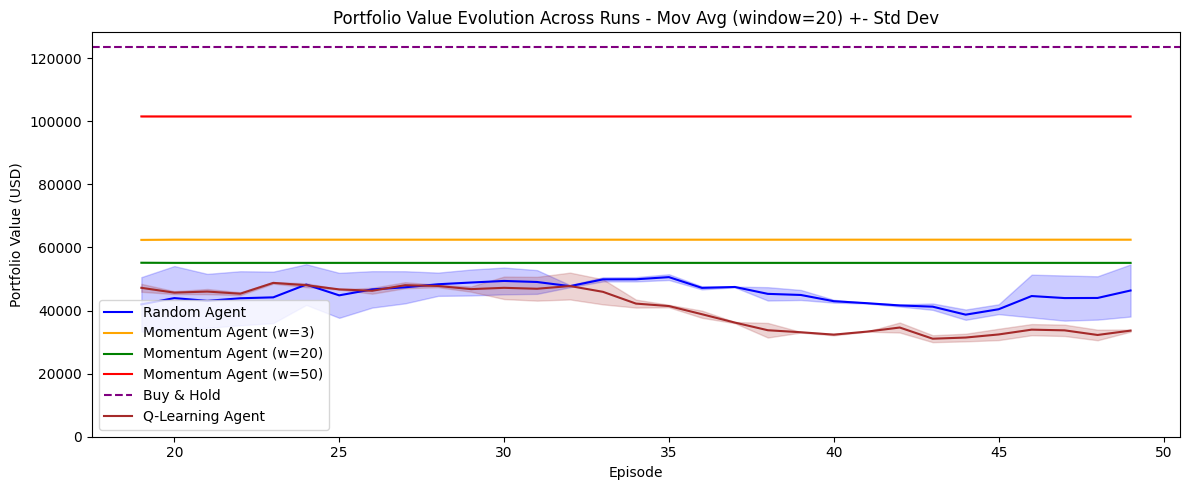

In [121]:
fig,ax = plt.subplots(figsize=(12, 5))
window = 20 # Moving average window for smoothing the plot, not the momentum agent's internal window
plot_value_evolution(compilation_random_agent, label='Random Agent', ax=ax, window=window, color='blue')
plot_value_evolution(compilation_momentum_agent_w3, label='Momentum Agent (w=3)', ax=ax, window=window, color='orange')
plot_value_evolution(compilation_momentum_agent_w20, label='Momentum Agent (w=20)', ax=ax, window=window, color='green')
plot_value_evolution(compilation_momentum_agent_w50, label='Momentum Agent (w=50)', ax=ax, window=window, color='red')
ax.axhline(buy_hold_value, color='purple', linestyle='--', label='Buy & Hold')
plot_value_evolution(compilation_qlearning_agent, label='Q-Learning Agent', ax=ax, window=window, color='brown')
ax.set_ylim(bottom=0)
ax.set_title(f'Portfolio Value Evolution Across Runs - Mov Avg (window={window}) +- Std Dev')
ax.set_xlabel('Episode')
ax.set_ylabel('Portfolio Value (USD)')
ax.legend()
plt.tight_layout()
plt.show()

### Tabela: configuração → melhor retorno → média/variância

In [122]:
def agent_summary(name, config, all_results):
    final_values = [run[-1] for run in all_results]  # last episode value per run
    return {
        'Agent': name,
        'Configuration': config,
        'Best Value': round(max(final_values), 2),
        'Average': round(np.mean(final_values),2),
        'Std (final episode, across runs)': round(np.std(final_values), 2),
    }

rows = [
    agent_summary('Random', 'n/a', compilation_random_agent),
    agent_summary('Momentum', 'window=5', compilation_momentum_agent_w3),
    agent_summary('Momentum', 'window=20', compilation_momentum_agent_w20),
    agent_summary('Momentum', 'window=50', compilation_momentum_agent_w50),
    agent_summary('Buy & Hold', 'n/a', [[buy_hold_value]]),
    agent_summary('Q-Learning', 'a=0.1, gamma=0.9, eps=0.1, eps_dec=0.995', compilation_qlearning_agent)
]

summary_df = pd.DataFrame(rows)
summary_df

,Agent,Configuration,Best Value,Average,"Std (final episode, across runs)"
0,Random,n/a,132076.81,82228.25,49848.56
1,Momentum,window=5,62460.83,62460.83,0.00
2,Momentum,window=20,55105.19,55105.19,0.00
3,Momentum,window=50,101522.47,101522.47,0.00
4,Buy & Hold,n/a,123502.80,123502.80,0.00
5,Q-Learning,"a=0.1, gamma=0.9, eps=0.1, eps_dec=0.995",78551.39,41623.39,36928.00


## Primeiro checkpoint para discussão

1. Momentum agent: 
- É deterministico, a partir do momento que a política está definida, não há aprendizagem. 
- Alterando o tamanho da janela conseguimos variar a performance. 
- A janela tem de estar de acordo com o timestep que estamos a utilizar, porque a voltalidade do preço depende desse timestep. 

2. Random agent: 
- A variância diminui, mas volta a aumentar, como era esperado, pois o agente não aprende.
- O facto de valor médio ficar sempre em torno do mesmo valor para cada run, demonstra o ponto anterior.

3. Buy & Hold strategy: 
- Aqui enviesado por termos ticker da Apple que teve um crescimento brutal, mas tentou-se compensar com a inclusão da Nokia. 
- Ainda assim, será interessante estudar a relevância de uma estratégia de gestão activa vs gestão passiva.

4. Q-learning: 
- Valor final médio mais baixo de todos os agentes experimentados até agora. 
- O melhor valor também é o mais baixo de todos. 
- Isto é um sinal de uma política demasiado greedy inicialmente, que faz com que o agente não explore o suficiente e aprenda uma política sub-optima. 
- Além disso, 50 episódios seja pouco para passar em todos os estados, dado que ainda não foi feita qualquer discretização.

## Q-learning: (segundo teste) → Variar epsilon_decay

### Neste teste, reduz-se o epsilon_decay, aumentando o valor de 0.995 para 0.999, para perceber se altera o comportamento do agente e ele não fica preso numa política sub-optima.

In [123]:
n_runs = 2
n_episodes_per_run = 50

compilation_qlearning_agent_2 = []
compilation_qlearning_agents_2 = []

for seed in range(n_runs):
    np.random.seed(seed)
    agent = qlearning_agent(
        num_actions = len(env.index_actions), 
        num_companies = env.total_companies,
        alpha=0.1, 
        gamma=0.95, 
        epsilon=1.0, 
        epsilon_decay=0.999, 
        epsilon_min=0.01
        )
    run_values = []

    for episode in range(n_episodes_per_run):
        state = env.start() # initialize environment and get initial state
        done = False # flag to indicate when episode is finished

        while not done:
            action = agent.act(state) # pick action
            next_state, reward, done = env.new_day(action) # step environment forward
            agent.learn(state, action, reward, next_state, done) # update Q table with learn method
            state = next_state # update state for next iteration

        run_values.append(env.get_episode_value()) # store final evaluation for this episode

    compilation_qlearning_agent_2.append(run_values) # complilation continues to be a list of lists, where each inner list is the episode values
    compilation_qlearning_agents_2.append(agent)  # store agent after each run

### Além disso, vamos testar runs de 50 episódios com epsilon fixo.

In [124]:
n_runs = 2
n_episodes_per_run = 50

compilation_qlearning_agent_3 = []
compilation_qlearning_agents_3 = []

for seed in range(n_runs):
    np.random.seed(seed)
    agent = qlearning_agent(
        num_actions = len(env.index_actions), 
        num_companies = env.total_companies,
        alpha=0.1, 
        gamma=0.95, 
        epsilon=1.0, 
        epsilon_decay=1, 
        epsilon_min=0.01
        )
    run_values = []

    for episode in range(n_episodes_per_run):
        state = env.start() # initialize environment and get initial state
        done = False # flag to indicate when episode is finished

        while not done:
            action = agent.act(state) # pick action
            next_state, reward, done = env.new_day(action) # step environment forward
            agent.learn(state, action, reward, next_state, done) # update Q table with learn method
            state = next_state # update state for next iteration

        run_values.append(env.get_episode_value()) # store final evaluation for this episode

    compilation_qlearning_agent_3.append(run_values) # complilation continues to be a list of lists, where each inner list is the episode values
    compilation_qlearning_agents_3.append(agent)  # store agent after each run

## Análise: Evolução do **retorno/valor do episódio** ao longo do treino

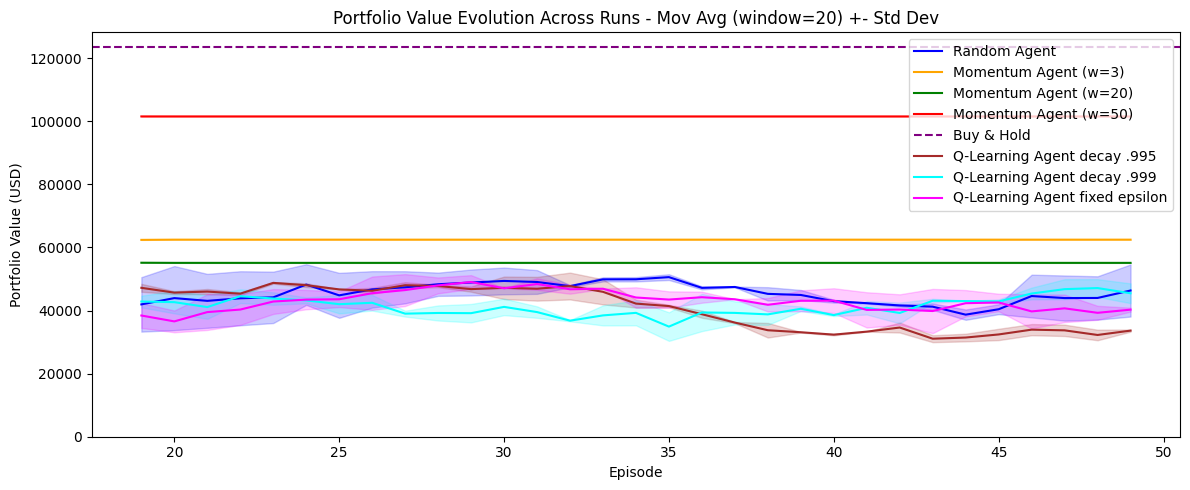

In [125]:
fig,ax = plt.subplots(figsize=(12, 5))
window = 20 # Moving average window for smoothing the plot, not the momentum agent's internal window
plot_value_evolution(compilation_random_agent, label='Random Agent', ax=ax, window=window, color='blue')
plot_value_evolution(compilation_momentum_agent_w3, label='Momentum Agent (w=3)', ax=ax, window=window, color='orange')
plot_value_evolution(compilation_momentum_agent_w20, label='Momentum Agent (w=20)', ax=ax, window=window, color='green')
plot_value_evolution(compilation_momentum_agent_w50, label='Momentum Agent (w=50)', ax=ax, window=window, color='red')
ax.axhline(buy_hold_value, color='purple', linestyle='--', label='Buy & Hold')
plot_value_evolution(compilation_qlearning_agent, label='Q-Learning Agent decay .995', ax=ax, window=window, color='brown')
plot_value_evolution(compilation_qlearning_agent_2, label='Q-Learning Agent decay .999', ax=ax, window=window, color='cyan')
plot_value_evolution(compilation_qlearning_agent_3, label='Q-Learning Agent fixed epsilon', ax=ax, window=window, color='magenta')
ax.set_ylim(bottom=0)
ax.set_title(f'Portfolio Value Evolution Across Runs - Mov Avg (window={window}) +- Std Dev')
ax.set_xlabel('Episode')
ax.set_ylabel('Portfolio Value (USD)')
ax.legend()
plt.tight_layout()
plt.show()

In [152]:
rows = [
    agent_summary('Random', 'n/a', compilation_random_agent),
    agent_summary('Momentum', 'window=5', compilation_momentum_agent_w3),
    agent_summary('Momentum', 'window=20', compilation_momentum_agent_w20),
    agent_summary('Momentum', 'window=50', compilation_momentum_agent_w50),
    agent_summary('Buy & Hold', 'n/a', [[buy_hold_value]]),
    agent_summary('Q-Learning', 'a=0.1, gamma=0.9, eps=1, eps_dec=0.995', compilation_qlearning_agent),
    agent_summary('Q-Learning', 'a=0.1, gamma=0.9, eps=1, eps_dec=0.999', compilation_qlearning_agent_2),
    agent_summary('Q-Learning', 'a=0.1, gamma=0.9, eps=1, eps_dec=Fixed', compilation_qlearning_agent_3)
]

summary_df = pd.DataFrame(rows)
summary_df

,Agent,Configuration,Best Value,Average,"Std (final episode, across runs)"
0,Random,n/a,132076.81,82228.25,49848.56
1,Momentum,window=5,62460.83,62460.83,0.00
2,Momentum,window=20,55105.19,55105.19,0.00
3,Momentum,window=50,101522.47,101522.47,0.00
4,Buy & Hold,n/a,123502.80,123502.80,0.00
5,Q-Learning,"a=0.1, gamma=0.9, eps=1, eps_dec=0.995",78551.39,41623.39,36928.00
6,Q-Learning,"a=0.1, gamma=0.9, eps=1, eps_dec=0.999",26338.30,22147.27,4191.03
7,Q-Learning,"a=0.1, gamma=0.9, eps=1, eps_dec=Fixed",78763.07,59262.29,19500.78


## Segundo checkpoint para discussão

1. Q-learning: 
- reduzir o epsilon-decay, garantindo uma maior exploração inicial, não parece ter ajudado.
- apenas demonstra que o agente pode estar a aprender mas continua a tomar ações aleatórias.
- isto também indica que o espaço de estados/ações é demasiado grande para ser explorado porque não foi feita qualquer discretização. 
- por essa razão, o próximo passo que faz sentido é discretizar.

## Espaço de estados (Discretização)

O espaço teórico é infinito (contínuo), ou seja, cada dia tem preços únicos e cada combinação (stocks, price, cash) é quase sempre única.

Abaixo podemos ver que o agente foi capaz de "passar" em 203 mil de estados do mercado, mas apenas pode tomar uma das ações, pelo que visita apenas 11.11% de estados visitados de uma ifinidade de possibilidades.

Além disso, na célula abaixo que virtualmente 0.0% dos estados são visitados mais que uma vez.

Com isto justifica-se a necessidade de **DISCRETIZAÇÃO**

In [127]:
total_states_visited = len(agent.Q)
total_entries = total_states_visited * len(env.index_actions)
percentage_pairs_visited = total_states_visited / total_entries * 100

print(f"Unique states visited:     {total_states_visited}")
print(f"Total Q-table entries:     {total_entries}")
print(f"Actions per state:         {len(env.index_actions)}")
print(f"Percentage of state-action pairs visited: {percentage_pairs_visited:.2f}%")

Unique states visited:     203455
Total Q-table entries:     1831095
Actions per state:         9
Percentage of state-action pairs visited: 11.11%


In [128]:
for i, a in enumerate(compilation_qlearning_agents_3):
    a.q_table_stats(run=i+1)

--- Run 1 ---
Unique states visited:          203466
States visited more than once:  55 / 203466 (0.0%)
Total Q-table entries:          1831194
Actions per state:              9
Current epsilon:                1.0000
--- Run 2 ---
Unique states visited:          203455
States visited more than once:  62 / 203455 (0.0%)
Total Q-table entries:          1831095
Actions per state:              9
Current epsilon:                1.0000


## Q-learning: state abstraction → discretização baseada na volatilidade

In [129]:
n_runs = 2
n_episodes_per_run = 50

compilation_qlearning_agent_4 = []
compilation_qlearning_agents_4 = []

for seed in range(n_runs):
    np.random.seed(seed)
    agent = qlearning_agent(
        num_actions = len(env.index_actions), 
        num_companies = env.total_companies,
        alpha=0.1, 
        gamma=0.95, 
        epsilon=1.0, 
        epsilon_decay=0.999, 
        epsilon_min=0.01
        )
    run_values = []

    for episode in range(n_episodes_per_run):
        env.start()
        state = env.get_discretized_state() # volatility + holdings
        done = False

        while not done:
            action = agent.act(state)
            _, reward, done = env.new_day(action)
            next_state = env.get_discretized_state() # volatility + holdings
            agent.learn(state, action, reward, next_state, done)
            state = next_state

        run_values.append(env.get_episode_value())

    compilation_qlearning_agent_4.append(run_values)
    compilation_qlearning_agents_4.append(agent)

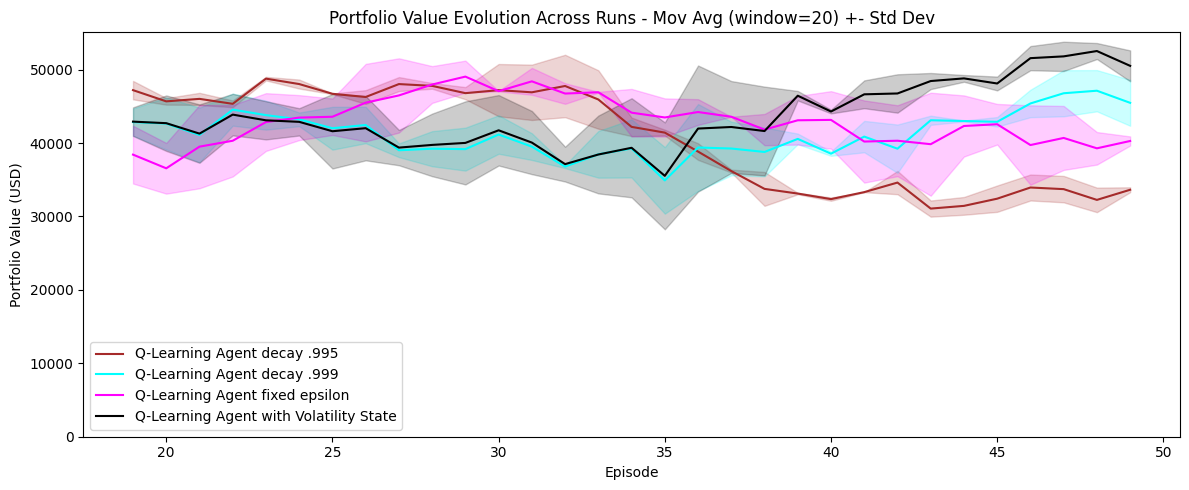

In [153]:
fig,ax = plt.subplots(figsize=(12, 5))
window = 20 # Moving average window for smoothing the plot, not the momentum agent's internal window
#plot_value_evolution(compilation_random_agent, label='Random Agent', ax=ax, window=window, color='blue')
#plot_value_evolution(compilation_momentum_agent_w3, label='Momentum Agent (w=3)', ax=ax, window=window, color='orange')
#plot_value_evolution(compilation_momentum_agent_w20, label='Momentum Agent (w=20)', ax=ax, window=window, color='green')
#plot_value_evolution(compilation_momentum_agent_w50, label='Momentum Agent (w=50)', ax=ax, window=window, color='red')
#ax.axhline(buy_hold_value, color='purple', linestyle='--', label='Buy & Hold')
plot_value_evolution(compilation_qlearning_agent, label='Q-Learning Agent decay .995', ax=ax, window=window, color='brown')
plot_value_evolution(compilation_qlearning_agent_2, label='Q-Learning Agent decay .999', ax=ax, window=window, color='cyan')
plot_value_evolution(compilation_qlearning_agent_3, label='Q-Learning Agent fixed epsilon', ax=ax, window=window, color='magenta')
plot_value_evolution(compilation_qlearning_agent_4, label='Q-Learning Agent with Volatility State', ax=ax, window=window, color='black')
ax.set_ylim(bottom=0)
ax.set_title(f'Portfolio Value Evolution Across Runs - Mov Avg (window={window}) +- Std Dev')
ax.set_xlabel('Episode')
ax.set_ylabel('Portfolio Value (USD)')
ax.legend()
plt.tight_layout()
plt.show()

In [154]:
rows = [
    agent_summary('Random', 'n/a', compilation_random_agent),
    agent_summary('Momentum', 'window=5', compilation_momentum_agent_w3),
    agent_summary('Momentum', 'window=20', compilation_momentum_agent_w20),
    agent_summary('Momentum', 'window=50', compilation_momentum_agent_w50),
    agent_summary('Buy & Hold', 'n/a', [[buy_hold_value]]),
    agent_summary('Q-Learning', 'a=0.1, gamma=0.9, eps=1, eps_dec=0.995', compilation_qlearning_agent),
    agent_summary('Q-Learning', 'a=0.1, gamma=0.9, eps=1, eps_dec=0.999', compilation_qlearning_agent_2),
    agent_summary('Q-Learning', 'a=0.1, gamma=0.9, eps=1, eps_dec=Fixed', compilation_qlearning_agent_3),
    agent_summary('Q-Learning', 'a=0.1, gamma=0.9, eps=1, eps_dec=0.999 + Volatility State', compilation_qlearning_agent_4)
]

summary_df = pd.DataFrame(rows)
summary_df

,Agent,Configuration,Best Value,Average,"Std (final episode, across runs)"
0,Random,n/a,132076.81,82228.25,49848.56
1,Momentum,window=5,62460.83,62460.83,0.00
2,Momentum,window=20,55105.19,55105.19,0.00
3,Momentum,window=50,101522.47,101522.47,0.00
4,Buy & Hold,n/a,123502.80,123502.80,0.00
5,Q-Learning,"a=0.1, gamma=0.9, eps=1, eps_dec=0.995",78551.39,41623.39,36928.00
6,Q-Learning,"a=0.1, gamma=0.9, eps=1, eps_dec=0.999",26338.30,22147.27,4191.03
7,Q-Learning,"a=0.1, gamma=0.9, eps=1, eps_dec=Fixed",78763.07,59262.29,19500.78
8,Q-Learning,"a=0.1, gamma=0.9, eps=1, eps_dec=0.999 + Volat...",29121.13,23937.78,5183.35


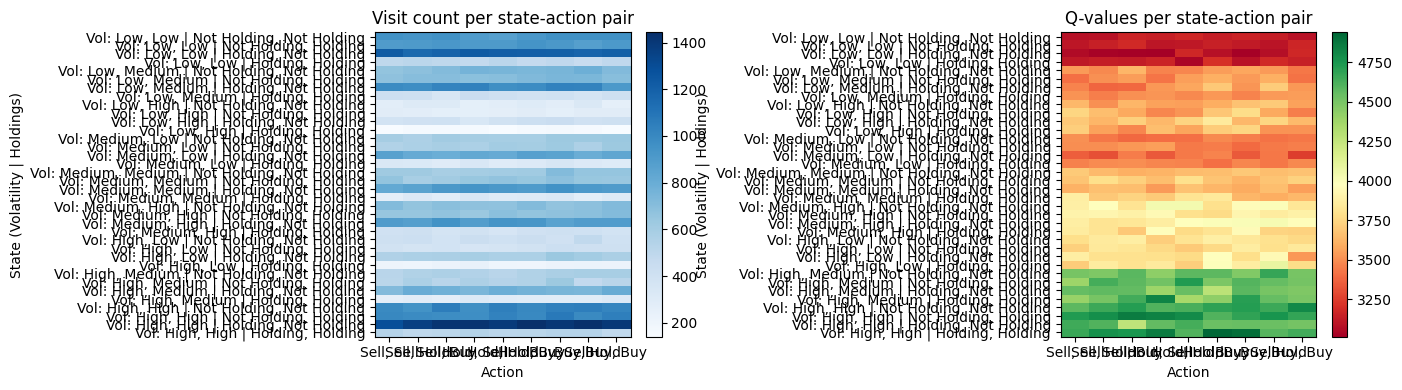

In [132]:
vol_labels = {0: 'Low', 1: 'Medium', 2: 'High'}

def state_label(s):
    n = len(s) // 2
    vol_part     = ', '.join(vol_labels[v] for v in s[:n])
    holding_part = ', '.join('Holding' if v else 'Not Holding' for v in s[n:])
    return f"Vol: {vol_part} | {holding_part}"

action_labels = {0: 'Sell', 1: 'Hold', 2: 'Buy'}

def action_label(a):
    return ', '.join(action_labels[v] for v in env.action_list[a])

agent = compilation_qlearning_agents_4[-1]
states = sorted(agent.Q.keys())
n_states = len(states)
n_actions = len(env.index_actions)
y_labels = [state_label(s) for s in states]
x_labels = [action_label(a) for a in range(n_actions)]

# build matrices
visit_matrix = np.zeros((n_states, n_actions))
q_matrix = np.zeros((n_states, n_actions))
for i, s in enumerate(states):
    for a in range(n_actions):
        visit_matrix[i, a] = agent.state_action_visits.get((s, a), 0)
        q_matrix[i, a] = agent.Q[s][a]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

im1 = axes[0].imshow(visit_matrix, aspect='auto', cmap='Blues')
axes[0].set_title('Visit count per state-action pair')
axes[0].set_xlabel('Action')
axes[0].set_ylabel('State (Volatility | Holdings)')
axes[0].set_xticks(range(n_actions))
axes[0].set_xticklabels(x_labels, rotation=0, ha='center')
axes[0].set_yticks(range(n_states))
axes[0].set_yticklabels(y_labels)
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(q_matrix, aspect='auto', cmap='RdYlGn')
axes[1].set_title('Q-values per state-action pair')
axes[1].set_xlabel('Action')
axes[1].set_ylabel('State (Volatility | Holdings)')
axes[1].set_xticks(range(n_actions))
axes[1].set_xticklabels(x_labels, rotation=0, ha='center')
axes[1].set_yticks(range(n_states))
axes[1].set_yticklabels(y_labels)
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

## Terceiro checkpoint para discussão

1. Q-learning: 
- O heatmap de visitas à esquerda mostra que todos os estados são visitados, mostrando uma cobertura uniforme - o agente explirou bem o espaço.
- A discretização solucionou parte do problema e o agente parece conseguir aprender.
- Acrescentar apenas a volatidade e discretizar com base parece não ter tido grande efeito.
- Ou seja, o sinal de volatilidade não está a acrescentar valor discriminativo suficiente para superar uma estratégia buy & hold simples ou até random.

Uma coisa que se pode tentar é fazer reward shaping e obter variação percentual de preço diária para ser comparável à volatilidade.

## Q-learning → reward shaping

In [133]:
n_runs = 2
n_episodes_per_run = 50

compilation_qlearning_agent_norm = []
compilation_qlearning_agents_norm = []

for seed in range(n_runs):
    np.random.seed(seed)
    agent = qlearning_agent(
        num_actions = len(env.index_actions), 
        num_companies = env.total_companies,
        alpha=0.1, 
        gamma=0.95, 
        epsilon=1.0, 
        epsilon_decay=0.999, 
        epsilon_min=0.01
        )
    run_values = []

    for episode in range(n_episodes_per_run):
        env.start()
        state = env.get_discretized_state() # volatility + holdings
        done = False

        while not done:
            action = agent.act(state)
            _, reward_normalized, done = env.new_day_normalized(action)  # normalised reward
            next_state = env.get_discretized_state() # volatility + holdings
            agent.learn(state, action, reward_normalized, next_state, done)
            state = next_state

        run_values.append(env.get_episode_value())

    compilation_qlearning_agent_norm.append(run_values)
    compilation_qlearning_agents_norm.append(agent)

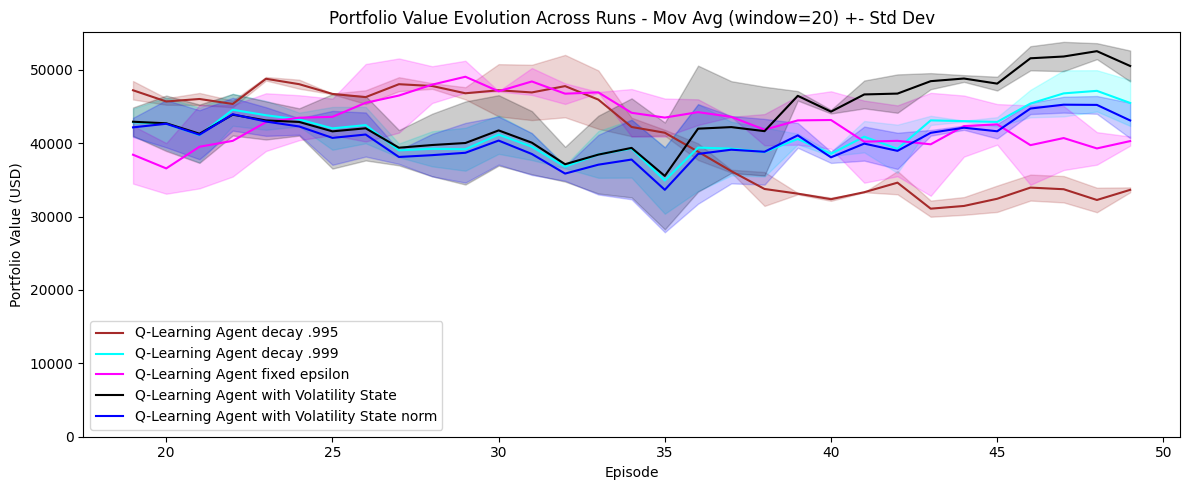

In [134]:
fig,ax = plt.subplots(figsize=(12, 5))
window = 20 # Moving average window for smoothing the plot, not the momentum agent's internal window
#plot_value_evolution(compilation_random_agent, label='Random Agent', ax=ax, window=window, color='blue')
#plot_value_evolution(compilation_momentum_agent_w3, label='Momentum Agent (w=3)', ax=ax, window=window, color='orange')
#plot_value_evolution(compilation_momentum_agent_w20, label='Momentum Agent (w=20)', ax=ax, window=window, color='green')
#plot_value_evolution(compilation_momentum_agent_w50, label='Momentum Agent (w=50)', ax=ax, window=window, color='red')
#ax.axhline(buy_hold_value, color='purple', linestyle='--', label='Buy & Hold')
plot_value_evolution(compilation_qlearning_agent, label='Q-Learning Agent decay .995', ax=ax, window=window, color='brown')
plot_value_evolution(compilation_qlearning_agent_2, label='Q-Learning Agent decay .999', ax=ax, window=window, color='cyan')
plot_value_evolution(compilation_qlearning_agent_3, label='Q-Learning Agent fixed epsilon', ax=ax, window=window, color='magenta')
plot_value_evolution(compilation_qlearning_agent_4, label='Q-Learning Agent with Volatility State', ax=ax, window=window, color='black')
plot_value_evolution(compilation_qlearning_agent_norm, label='Q-Learning Agent with Volatility State norm', ax=ax, window=window, color='blue')
ax.set_ylim(bottom=0)
ax.set_title(f'Portfolio Value Evolution Across Runs - Mov Avg (window={window}) +- Std Dev')
ax.set_xlabel('Episode')
ax.set_ylabel('Portfolio Value (USD)')
ax.legend()
plt.tight_layout()
plt.show()

In [135]:
rows = [
    agent_summary('Random', 'n/a', compilation_random_agent),
    agent_summary('Momentum', 'window=5', compilation_momentum_agent_w3),
    agent_summary('Momentum', 'window=20', compilation_momentum_agent_w20),
    agent_summary('Momentum', 'window=50', compilation_momentum_agent_w50),
    agent_summary('Buy & Hold', 'n/a', [[buy_hold_value]]),
    agent_summary('Q-Learning', 'a=0.1, gamma=0.9, eps=1, eps_dec=0.995', compilation_qlearning_agent),
    agent_summary('Q-Learning', 'a=0.1, gamma=0.9, eps=1, eps_dec=0.999', compilation_qlearning_agent_2),
    agent_summary('Q-Learning', 'a=0.1, gamma=0.9, eps=1, eps_dec=Fixed', compilation_qlearning_agent_3),
    agent_summary('Q-Learning', 'a=0.1, gamma=0.9, eps=1, eps_dec=0.999 + Volatility State', compilation_qlearning_agent_4),
    agent_summary('Q-Learning', 'a=0.1, gamma=0.9, eps=1, eps_dec=0.999 + Volatility State Norm', compilation_qlearning_agent_norm)
]

summary_df = pd.DataFrame(rows)
summary_df

,Agent,Configuration,Best Value,Average,"Std (final episode, across runs)"
0,Random,n/a,132076.81,82228.25,49848.56
1,Momentum,window=5,62460.83,62460.83,0.00
2,Momentum,window=20,55105.19,55105.19,0.00
3,Momentum,window=50,101522.47,101522.47,0.00
4,Buy & Hold,n/a,123502.80,123502.80,0.00
5,Q-Learning,"a=0.1, gamma=0.9, eps=1, eps_dec=0.995",78551.39,41623.39,36928.00
6,Q-Learning,"a=0.1, gamma=0.9, eps=1, eps_dec=0.999",26338.30,22147.27,4191.03
7,Q-Learning,"a=0.1, gamma=0.9, eps=1, eps_dec=Fixed",78763.07,59262.29,19500.78
8,Q-Learning,"a=0.1, gamma=0.9, eps=1, eps_dec=0.999 + Volat...",29121.13,23937.78,5183.35
9,Q-Learning,"a=0.1, gamma=0.9, eps=1, eps_dec=0.999 + Volat...",21707.45,17465.11,4242.34


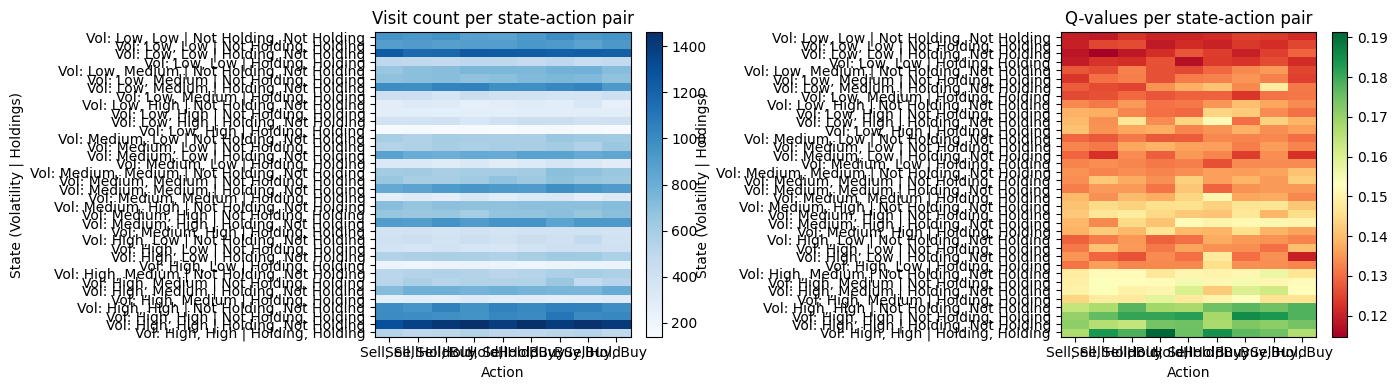

In [136]:
vol_labels = {0: 'Low', 1: 'Medium', 2: 'High'}

def state_label(s):
    n = len(s) // 2
    vol_part     = ', '.join(vol_labels[v] for v in s[:n])
    holding_part = ', '.join('Holding' if v else 'Not Holding' for v in s[n:])
    return f"Vol: {vol_part} | {holding_part}"

action_labels = {0: 'Sell', 1: 'Hold', 2: 'Buy'}

def action_label(a):
    return ', '.join(action_labels[v] for v in env.action_list[a])

agent = compilation_qlearning_agents_norm[-1]
states = sorted(agent.Q.keys())
n_states = len(states)
n_actions = len(env.index_actions)
y_labels = [state_label(s) for s in states]
x_labels = [action_label(a) for a in range(n_actions)]

# build matrices
visit_matrix = np.zeros((n_states, n_actions))
q_matrix = np.zeros((n_states, n_actions))
for i, s in enumerate(states):
    for a in range(n_actions):
        visit_matrix[i, a] = agent.state_action_visits.get((s, a), 0)
        q_matrix[i, a] = agent.Q[s][a]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

im1 = axes[0].imshow(visit_matrix, aspect='auto', cmap='Blues')
axes[0].set_title('Visit count per state-action pair')
axes[0].set_xlabel('Action')
axes[0].set_ylabel('State (Volatility | Holdings)')
axes[0].set_xticks(range(n_actions))
axes[0].set_xticklabels(x_labels, rotation=0, ha='center')
axes[0].set_yticks(range(n_states))
axes[0].set_yticklabels(y_labels)
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(q_matrix, aspect='auto', cmap='RdYlGn')
axes[1].set_title('Q-values per state-action pair')
axes[1].set_xlabel('Action')
axes[1].set_ylabel('State (Volatility | Holdings)')
axes[1].set_xticks(range(n_actions))
axes[1].set_xticklabels(x_labels, rotation=0, ha='center')
axes[1].set_yticks(range(n_states))
axes[1].set_yticklabels(y_labels)
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

## Quarto checkpoint para discussão

1. Q-learning: 

- Reward shaping ainda não fez com que a performance melhorasse. 
- Mas o agente parece estar a aprender quando olhamos para o gráfico de Q-values (neste caso em função dos pares state-action onde o estado contém a volatididade, e o preço e as stocks em carteira)
- Uma coisa que conseguimos ver em relação à Q-table anteior é que agora temos maior dispersão de valores em cada linha, ou seja, o agente começa a diferenciar valor entre ações, o que antes não acontecia.
- Ainda assim apostar numa aprendizagem mais longa não parece boa estratégia quando ainda não temos qualquer indicação de melhoria

Em vez de aumentar o treino, vamos tentar acrescentar mais sinal.

## Q-learning + reward shaping (volatilidade e momento)

In [147]:
n_runs = 5
n_episodes_per_run = 50

compilation_qlearning_agent_norm_2_5x50 = []
compilation_qlearning_agents_norm_2_5x50 = []

for seed in range(n_runs):
    np.random.seed(seed)
    agent = qlearning_agent(
        num_actions = len(env.index_actions), 
        num_companies = env.total_companies,
        alpha=0.1, 
        gamma=0.95, 
        epsilon=1.0, 
        epsilon_decay=0.95, 
        epsilon_min=0.01
        )
    run_values = []

    for episode in range(n_episodes_per_run):
        env.start()
        state = env.get_discretized_state_v2() # volatility + holdings + momentum
        done = False

        while not done:
            action = agent.act(state)
            _, reward_normalized, done = env.new_day_normalized(action)  # normalised reward
            next_state = env.get_discretized_state() # volatility + holdings
            agent.learn(state, action, reward_normalized, next_state, done)
            state = next_state

        run_values.append(env.get_episode_value())

    compilation_qlearning_agent_norm_2_5x50.append(run_values)
    compilation_qlearning_agents_norm_2_5x50.append(agent)

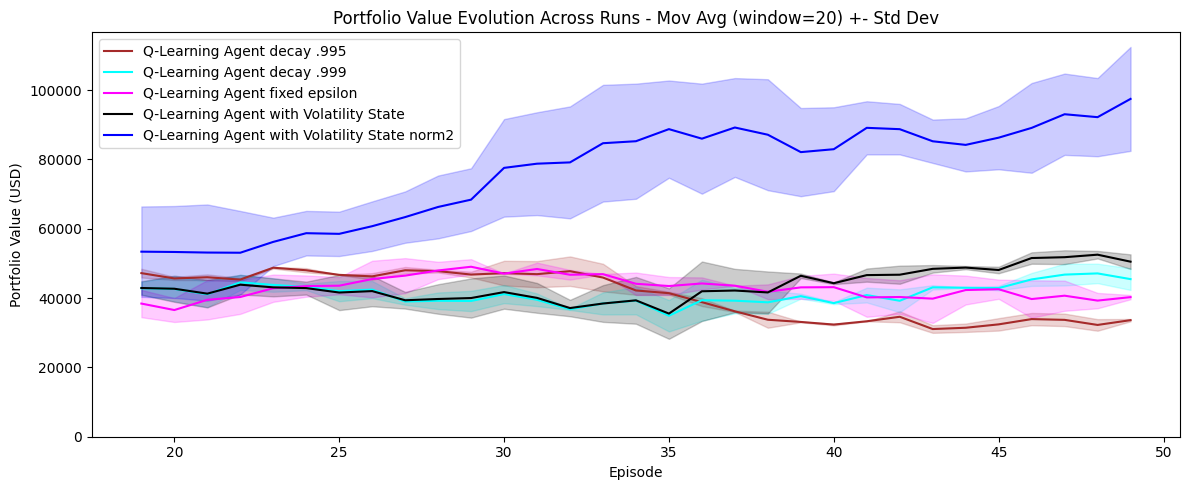

In [155]:
fig,ax = plt.subplots(figsize=(12, 5))
window = 20 # Moving average window for smoothing the plot, not the momentum agent's internal window
#plot_value_evolution(compilation_random_agent, label='Random Agent', ax=ax, window=window, color='blue')
#plot_value_evolution(compilation_momentum_agent_w3, label='Momentum Agent (w=3)', ax=ax, window=window, color='orange')
#plot_value_evolution(compilation_momentum_agent_w20, label='Momentum Agent (w=20)', ax=ax, window=window, color='green')
#plot_value_evolution(compilation_momentum_agent_w50, label='Momentum Agent (w=50)', ax=ax, window=window, color='red')
#ax.axhline(buy_hold_value, color='purple', linestyle='--', label='Buy & Hold')
plot_value_evolution(compilation_qlearning_agent, label='Q-Learning Agent decay .995', ax=ax, window=window, color='brown')
plot_value_evolution(compilation_qlearning_agent_2, label='Q-Learning Agent decay .999', ax=ax, window=window, color='cyan')
plot_value_evolution(compilation_qlearning_agent_3, label='Q-Learning Agent fixed epsilon', ax=ax, window=window, color='magenta')
plot_value_evolution(compilation_qlearning_agent_4, label='Q-Learning Agent with Volatility State', ax=ax, window=window, color='black')
plot_value_evolution(compilation_qlearning_agent_norm_2_5x50, label='Q-Learning Agent with Volatility State norm2', ax=ax, window=window, color='blue')
ax.set_ylim(bottom=0)
ax.set_title(f'Portfolio Value Evolution Across Runs - Mov Avg (window={window}) +- Std Dev')
ax.set_xlabel('Episode')
ax.set_ylabel('Portfolio Value (USD)')
ax.legend()
plt.tight_layout()
plt.show()

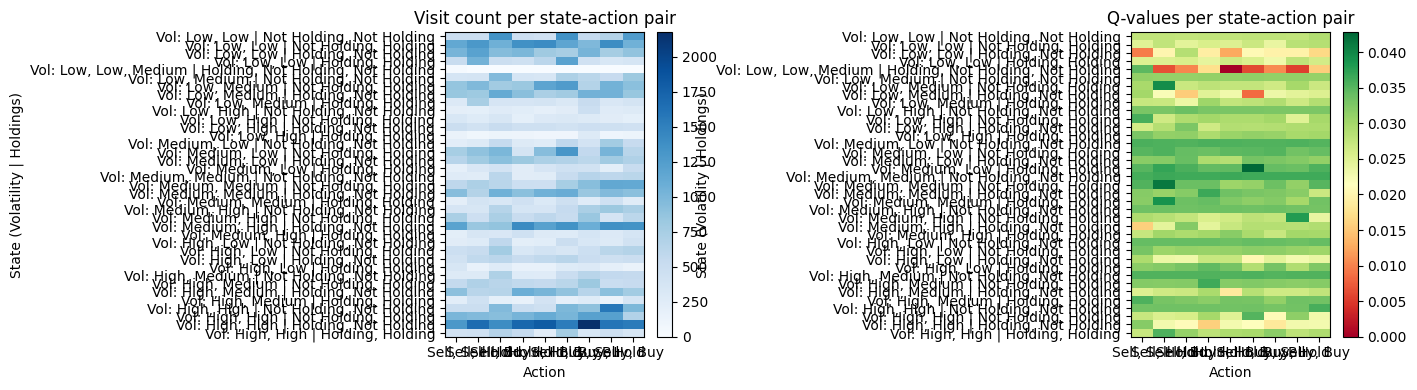

In [ ]:
vol_labels = {0: 'Low', 1: 'Medium', 2: 'High'}

def state_label(s):
    n = len(s) // 2
    vol_part     = ', '.join(vol_labels[v] for v in s[:n])
    holding_part = ', '.join('Holding' if v else 'Not Holding' for v in s[n:])
    return f"Vol: {vol_part} | {holding_part}"

action_labels = {0: 'Sell', 1: 'Hold', 2: 'Buy'}

def action_label(a):
    return ', '.join(action_labels[v] for v in env.action_list[a])

agent = compilation_qlearning_agents_norm_2_5x50[-1]
states = sorted(agent.Q.keys())
n_states = len(states)
n_actions = len(env.index_actions)
y_labels = [state_label(s) for s in states]
x_labels = [action_label(a) for a in range(n_actions)]

# build matrices
visit_matrix = np.zeros((n_states, n_actions))
q_matrix = np.zeros((n_states, n_actions))
for i, s in enumerate(states):
    for a in range(n_actions):
        visit_matrix[i, a] = agent.state_action_visits.get((s, a), 0)
        q_matrix[i, a] = agent.Q[s][a]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

im1 = axes[0].imshow(visit_matrix, aspect='auto', cmap='Blues')
axes[0].set_title('Visit count per state-action pair')
axes[0].set_xlabel('Action')
axes[0].set_ylabel('State (Volatility | Holdings)')
axes[0].set_xticks(range(n_actions))
axes[0].set_xticklabels(x_labels, rotation=0, ha='center')
axes[0].set_yticks(range(n_states))
axes[0].set_yticklabels(y_labels)
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(q_matrix, aspect='auto', cmap='RdYlGn')
axes[1].set_title('Q-values per state-action pair')
axes[1].set_xlabel('Action')
axes[1].set_ylabel('State (Volatility | Holdings)')
axes[1].set_xticks(range(n_actions))
axes[1].set_xticklabels(x_labels, rotation=0, ha='center')
axes[1].set_yticks(range(n_states))
axes[1].set_yticklabels(y_labels)
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

## Quinto checkpoint para discussão

1. Q-learning: 

- Finalmente chegamos a um agente que está realmente a aprender E a melhorar a performance.
- O agente azul escuro é claramente o melhor resultado obtido de entre os agentes Q-learning.
- O elevado desvio padrão demonstra alta variância entre runs, o que indica que a política aprendida é sensível à seed e além disso não demonstra estabilização.
- Alguns pares estado-ação específicos agora estão muito marcados, ou seja, o agente foi capaz de aprender políticas específicas. Tanto positivos como negativos.
- A adição do momento criou mais diferenciação entre estados

Mais episódios provavelmente reduziriam a variância e aumentariam o valor médio.

In [146]:
n_runs = 1
n_episodes_per_run = 100

compilation_qlearning_agent_norm_2_100 = []
compilation_qlearning_agents_norm_2_100 = []

for seed in range(n_runs):
    np.random.seed(seed)
    agent = qlearning_agent(
        num_actions = len(env.index_actions), 
        num_companies = env.total_companies,
        alpha=0.1, 
        gamma=0.95, 
        epsilon=1.0, 
        epsilon_decay=0.95, 
        epsilon_min=0.01
        )
    run_values = []

    for episode in range(n_episodes_per_run):
        env.start()
        state = env.get_discretized_state_v2() # volatility + holdings + momentum
        done = False

        while not done:
            action = agent.act(state)
            _, reward_normalized, done = env.new_day_normalized(action)  # normalised reward
            next_state = env.get_discretized_state() # volatility + holdings
            agent.learn(state, action, reward_normalized, next_state, done)
            state = next_state

        run_values.append(env.get_episode_value())

    compilation_qlearning_agent_norm_2_100.append(run_values)
    compilation_qlearning_agents_norm_2_100.append(agent)

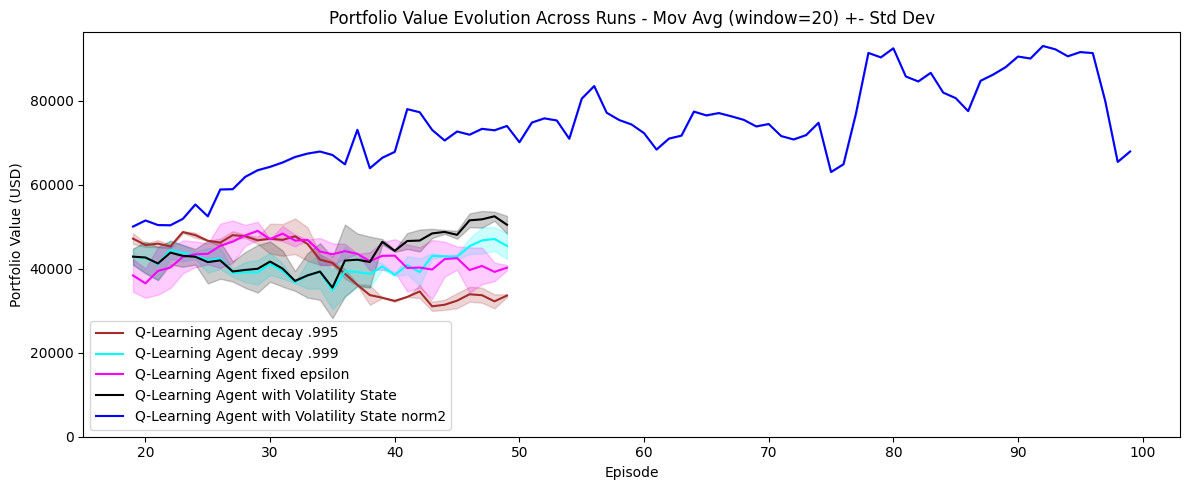

In [157]:
fig,ax = plt.subplots(figsize=(12, 5))
window = 20 # Moving average window for smoothing the plot, not the momentum agent's internal window
#plot_value_evolution(compilation_random_agent, label='Random Agent', ax=ax, window=window, color='blue')
#plot_value_evolution(compilation_momentum_agent_w3, label='Momentum Agent (w=3)', ax=ax, window=window, color='orange')
#plot_value_evolution(compilation_momentum_agent_w20, label='Momentum Agent (w=20)', ax=ax, window=window, color='green')
#plot_value_evolution(compilation_momentum_agent_w50, label='Momentum Agent (w=50)', ax=ax, window=window, color='red')
#ax.axhline(buy_hold_value, color='purple', linestyle='--', label='Buy & Hold')
plot_value_evolution(compilation_qlearning_agent, label='Q-Learning Agent decay .995', ax=ax, window=window, color='brown')
plot_value_evolution(compilation_qlearning_agent_2, label='Q-Learning Agent decay .999', ax=ax, window=window, color='cyan')
plot_value_evolution(compilation_qlearning_agent_3, label='Q-Learning Agent fixed epsilon', ax=ax, window=window, color='magenta')
plot_value_evolution(compilation_qlearning_agent_4, label='Q-Learning Agent with Volatility State', ax=ax, window=window, color='black')
plot_value_evolution(compilation_qlearning_agent_norm_2_100, label='Q-Learning Agent with Volatility State norm2', ax=ax, window=window, color='blue')
ax.set_ylim(bottom=0)
ax.set_title(f'Portfolio Value Evolution Across Runs - Mov Avg (window={window}) +- Std Dev')
ax.set_xlabel('Episode')
ax.set_ylabel('Portfolio Value (USD)')
ax.legend()
plt.tight_layout()
plt.show()